In [2]:
import pandas as pd

# Ler os arquivos avisando o Python que o separador é ponto-e-vírgula nos dois!
df_emendas = pd.read_csv('emendas 2022.csv', sep=';', encoding='latin-1')
df_votos = pd.read_csv('votacao_candidato_munzona_2022_RS.csv', encoding='latin-1', sep=';')

# Mostrar as colunas do arquivo de emendas
print("--- COLUNAS DO ARQUIVO DE EMENDAS ---")
print(df_emendas.columns.tolist())

print("\n" + "="*50 + "\n")

# Mostrar as colunas do arquivo de votos
print("--- COLUNAS DO ARQUIVO DE VOTOS ---")
print(df_votos.columns.tolist())

--- COLUNAS DO ARQUIVO DE EMENDAS ---
['ï»¿"Ano"', 'Tipo de Emenda', 'Autor da emenda', 'NÃºmero da emenda', 'Possui Apoiador/Solicitante?', 'Localidade do gasto (RegionalizaÃ§Ã£o)', 'FunÃ§Ã£o', 'SubfunÃ§Ã£o', 'Programa OrÃ§amentÃ¡rio', 'AÃ§Ã£o OrÃ§amentÃ¡ria', 'Plano OrÃ§amentÃ¡rio', 'CÃ³digo da emenda', 'Valor empenhado', 'Valor liquidado', 'Valor pago', 'Valor Restos a Pagar Inscritos', 'Valor Restos a Pagar Cancelados', 'Valor Restos a Pagar Pagos', 'Unnamed: 18']


--- COLUNAS DO ARQUIVO DE VOTOS ---
['DT_GERACAO', 'HH_GERACAO', 'ANO_ELEICAO', 'CD_TIPO_ELEICAO', 'NM_TIPO_ELEICAO', 'NR_TURNO', 'CD_ELEICAO', 'DS_ELEICAO', 'DT_ELEICAO', 'TP_ABRANGENCIA', 'SG_UF', 'SG_UE', 'NM_UE', 'CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'CD_CARGO', 'DS_CARGO', 'SQ_CANDIDATO', 'NR_CANDIDATO', 'NM_CANDIDATO', 'NM_URNA_CANDIDATO', 'NM_SOCIAL_CANDIDATO', 'CD_SITUACAO_CANDIDATURA', 'DS_SITUACAO_CANDIDATURA', 'CD_DETALHE_SITUACAO_CAND', 'DS_DETALHE_SITUACAO_CAND', 'CD_SITUACAO_JULGAMENTO', 'DS_SITUACAO_

In [3]:
# 1. Relendo o arquivo de emendas com a leitura correta de acentos (utf-8-sig)
df_emendas = pd.read_csv('emendas 2022.csv', sep=';', encoding='utf-8-sig')

# 2. Separando apenas as colunas que importam para o nosso projeto
emendas_uteis = df_emendas[['Autor da emenda', 'Localidade do gasto (Regionalização)', 'Valor pago']]

# 3. Separando as colunas do TSE (O df_votos já está na memória do Python da célula anterior)
votos_uteis = df_votos[['NM_CANDIDATO', 'NM_URNA_CANDIDATO', 'DS_CARGO', 'NM_MUNICIPIO', 'QT_VOTOS_NOMINAIS']]

# 4. Mostrar como ficou a nossa "mesa" limpa
print("--- AMOSTRA DE EMENDAS LIMPA ---")
print(emendas_uteis.head(3))

print("\n--- AMOSTRA DE VOTOS LIMPA ---")
print(votos_uteis.head(3))

--- AMOSTRA DE EMENDAS LIMPA ---
                     Autor da emenda Localidade do gasto (Regionalização)  \
0  5017 - COM. FINANCAS E TRIBUTACAO                             Nacional   
1               8100 - RELATOR GERAL                             Nacional   
2               3737 - ORLANDO SILVA                         DIADEMA - SP   

  Valor pago  
0       0,00  
1   8.037,30  
2       0,00  

--- AMOSTRA DE VOTOS LIMPA ---
               NM_CANDIDATO NM_URNA_CANDIDATO           DS_CARGO  \
0  EDERILDO PAPARICO BACCHI   PAPARICO BACCHI  Deputado Estadual   
1  EDERILDO PAPARICO BACCHI   PAPARICO BACCHI  Deputado Estadual   
2  EDERILDO PAPARICO BACCHI   PAPARICO BACCHI  Deputado Estadual   

             NM_MUNICIPIO  QT_VOTOS_NOMINAIS  
0  SANTA MARGARIDA DO SUL                 13  
1                  VIAMÃO                 14  
2               TUCUNDUVA                  0  


In [4]:
# 1. Fazemos uma cópia de segurança dos dados limpos
emendas_uteis = emendas_uteis.copy()

# 2. A magia da limpeza na coluna 'Valor pago'
emendas_uteis['Valor pago'] = (
    emendas_uteis['Valor pago']
    .astype(str)                          # Garante que tudo seja lido como texto primeiro
    .str.replace('R$', '', regex=False)   # Remove o 'R$' (se houver algum escondido)
    .str.replace("'", "", regex=False)    # Remove aquele apóstrofo maldito que você descobriu
    .str.replace(' ', '', regex=False)    # Remove qualquer espaço em branco
    .str.replace('.', '', regex=False)    # Remove o ponto dos milhares (ex: 8.037 vira 8037)
    .str.replace(',', '.', regex=False)   # Troca a vírgula decimal por ponto (ex: 30 vira .30)
    .astype(float)                        # Finalmente, transforma tudo em número puro!
)

# 3. Mostrar o resultado
print("--- VALORES DE EMENDAS APÓS A LIMPEZA ---")
print(emendas_uteis.head(3))

--- VALORES DE EMENDAS APÓS A LIMPEZA ---
                     Autor da emenda Localidade do gasto (Regionalização)  \
0  5017 - COM. FINANCAS E TRIBUTACAO                             Nacional   
1               8100 - RELATOR GERAL                             Nacional   
2               3737 - ORLANDO SILVA                         DIADEMA - SP   

   Valor pago  
0         0.0  
1      8037.3  
2         0.0  


In [5]:
import unicodedata

# Função rápida para arrancar acentos de qualquer palavra
def tirar_acentos(texto):
    if pd.isna(texto):
        return texto
    # Transforma em texto, remove acentos e deixa tudo em maiúsculo
    texto = str(texto)
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    return texto.upper().strip()

# Fazendo uma cópia segura dos votos para não dar erro
votos_uteis = votos_uteis.copy()

# 1. Limpando os POLÍTICOS nas emendas (Arrancando os números antes do traço)
# Ex: '3737 - ORLANDO SILVA' vira 'ORLANDO SILVA'
emendas_uteis['Político'] = emendas_uteis['Autor da emenda'].str.split(' - ').str[-1]

# 2. Limpando as CIDADES nas emendas (Arrancando a sigla do Estado depois do traço)
# Ex: 'DIADEMA - SP' vira 'DIADEMA'
emendas_uteis['Município'] = emendas_uteis['Localidade do gasto (Regionalização)'].str.split(' - ').str[0]

# 3. Aplicando a remoção de acentos nos municípios dos DOIS arquivos
emendas_uteis['Município'] = emendas_uteis['Município'].apply(tirar_acentos)
votos_uteis['NM_MUNICIPIO'] = votos_uteis['NM_MUNICIPIO'].apply(tirar_acentos)

# 4. Mostrar a nossa nova organização
print("--- EMENDAS PREPARADAS PARA CRUZAMENTO ---")
print(emendas_uteis[['Político', 'Município', 'Valor pago']].head(3))

print("\n--- VOTOS PREPARADOS PARA CRUZAMENTO ---")
print(votos_uteis[['NM_CANDIDATO', 'NM_URNA_CANDIDATO', 'NM_MUNICIPIO', 'QT_VOTOS_NOMINAIS']].head(3))

--- EMENDAS PREPARADAS PARA CRUZAMENTO ---
                     Político Município  Valor pago
0  COM. FINANCAS E TRIBUTACAO  NACIONAL         0.0
1               RELATOR GERAL  NACIONAL      8037.3
2               ORLANDO SILVA   DIADEMA         0.0

--- VOTOS PREPARADOS PARA CRUZAMENTO ---
               NM_CANDIDATO NM_URNA_CANDIDATO            NM_MUNICIPIO  \
0  EDERILDO PAPARICO BACCHI   PAPARICO BACCHI  SANTA MARGARIDA DO SUL   
1  EDERILDO PAPARICO BACCHI   PAPARICO BACCHI                  VIAMAO   
2  EDERILDO PAPARICO BACCHI   PAPARICO BACCHI               TUCUNDUVA   

   QT_VOTOS_NOMINAIS  
0                 13  
1                 14  
2                  0  


In [6]:
# 1. Filtrar a planilha de votos para deixar APENAS os Deputados Federais
votos_federais = votos_uteis[votos_uteis['DS_CARGO'].str.upper() == 'DEPUTADO FEDERAL'].copy()

# 2. Tirar os acentos dos nomes dos políticos para o cruzamento ser perfeito
votos_federais['NM_URNA_CANDIDATO'] = votos_federais['NM_URNA_CANDIDATO'].apply(tirar_acentos)
emendas_uteis['Político'] = emendas_uteis['Político'].apply(tirar_acentos)

# 3. Agrupar e Somar os Votos (caso a cidade tenha mais de uma zona eleitoral)
votos_agrupados = votos_federais.groupby(['NM_URNA_CANDIDATO', 'NM_MUNICIPIO'])['QT_VOTOS_NOMINAIS'].sum().reset_index()

# 4. Agrupar e Somar as Emendas (caso o deputado tenha mandado mais de uma emenda pra mesma cidade)
emendas_agrupadas = emendas_uteis.groupby(['Político', 'Município'])['Valor pago'].sum().reset_index()

# 5. Mostrar as planilhas finais prontas para o casamento
print("--- RESUMO FINAL: VOTOS ---")
print(votos_agrupados.head(3))

print("\n--- RESUMO FINAL: EMENDAS ---")
print(emendas_agrupadas.head(3))

--- RESUMO FINAL: VOTOS ---
  NM_URNA_CANDIDATO NM_MUNICIPIO  QT_VOTOS_NOMINAIS
0      ABRAO GODOIS       ACEGUA                  0
1      ABRAO GODOIS   AGUA SANTA                  1
2      ABRAO GODOIS        AGUDO                  0

--- RESUMO FINAL: EMENDAS ---
         Político             Município  Valor pago
0  ABILIO SANTANA            BAHIA (UF)         0.0
1  ABILIO SANTANA  CONCEICAO DO ALMEIDA    750141.0
2  ABILIO SANTANA        CRUZ DAS ALMAS         0.0


In [7]:
# 1. Renomeando as colunas para ficarem idênticas nas duas planilhas
votos_agrupados = votos_agrupados.rename(columns={
    'NM_URNA_CANDIDATO': 'CANDIDATO', 
    'NM_MUNICIPIO': 'MUNICIPIO'
})

emendas_agrupadas = emendas_agrupadas.rename(columns={
    'Político': 'CANDIDATO', 
    'Município': 'MUNICIPIO'
})

# 2. O Casamento (Merge): Juntando as planilhas onde Candidato e Município forem iguais
# O how='inner' significa que ele só vai manter as linhas onde houver "match" perfeito dos dois lados
dados_finais = pd.merge(votos_agrupados, emendas_agrupadas, on=['CANDIDATO', 'MUNICIPIO'], how='inner')

# 3. Organizar para vermos quem mandou mais dinheiro primeiro
dados_finais = dados_finais.sort_values(by='Valor pago', ascending=False)

# 4. Mostrar o resultado da nossa tabela unificada
print("--- DADOS CRUZADOS COM SUCESSO ---")
print(dados_finais.head())

--- DADOS CRUZADOS COM SUCESSO ---
              CANDIDATO         MUNICIPIO  QT_VOTOS_NOMINAIS  Valor pago
7   FERNANDA MELCHIONNA      PORTO ALEGRE              91749   3802435.0
3   FERNANDA MELCHIONNA            ESTEIO               2415   1086410.0
1          CARLOS GOMES        VILA MARIA                888    500000.0
17       LUCAS REDECKER     CAXIAS DO SUL               3153    400000.0
13       LUCAS REDECKER  BARRA DO RIBEIRO               1406    400000.0


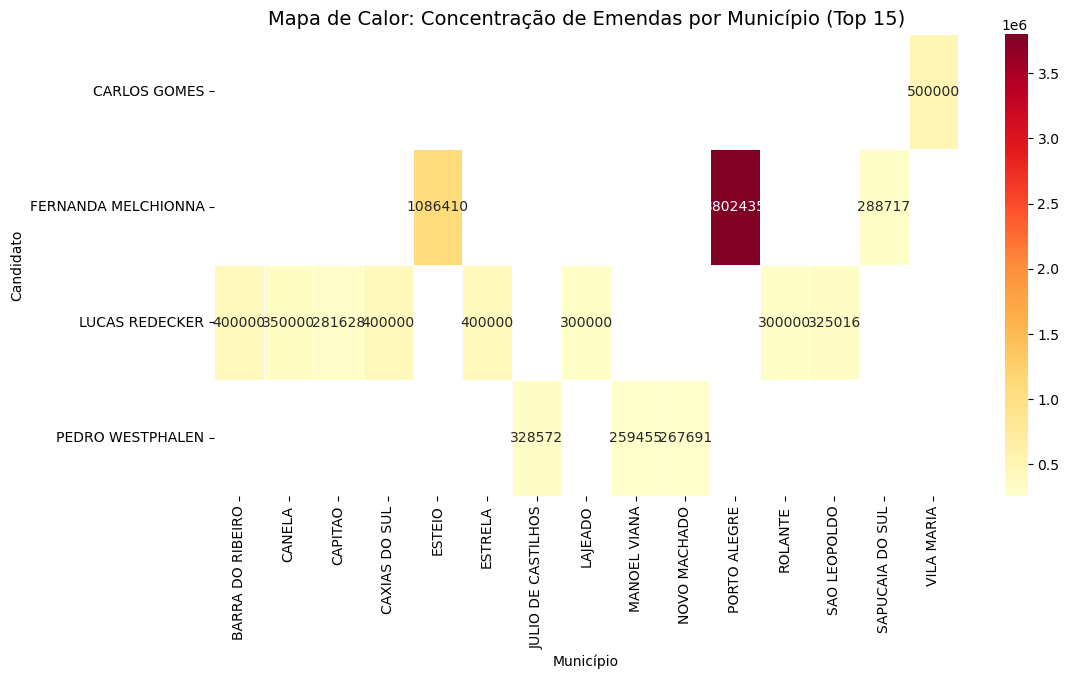

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pegar apenas os 15 maiores repasses para o gráfico ficar legível
top_dados = dados_finais.head(15)

# 2. Criar a "Matriz" do Mapa de Calor (Pivot Table)
# Linhas = Candidatos, Colunas = Municípios, Cores/Valores = Dinheiro
matriz_calor = top_dados.pivot_table(index='CANDIDATO', columns='MUNICIPIO', values='Valor pago')

# 3. Configurar o tamanho da "tela" de pintura (Largura, Altura)
plt.figure(figsize=(12, 6))

# 4. Desenhar o Mapa de Calor com a biblioteca Seaborn
# annot=True (mostra os números dentro dos quadrados)
# cmap='YlOrRd' (Paleta de cores: Yellow, Orange, Red)
sns.heatmap(matriz_calor, annot=True, cmap='YlOrRd', fmt='.0f', linewidths=.5)

# 5. Colocar os títulos para ficar profissional
plt.title('Mapa de Calor: Concentração de Emendas por Município (Top 15)', fontsize=14)
plt.xlabel('Município')
plt.ylabel('Candidato')

# 6. Exibir o gráfico na tela
plt.show()

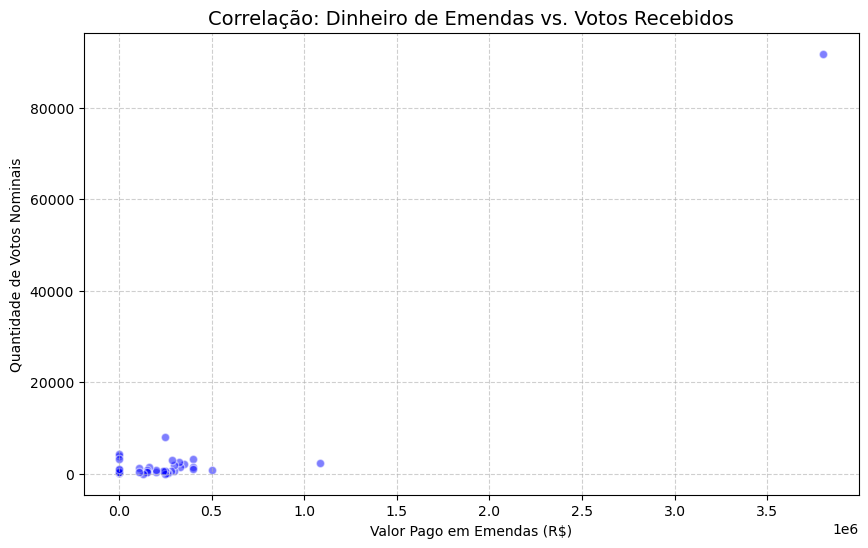

In [11]:
import matplotlib.pyplot as plt

# Criar a figura
plt.figure(figsize=(10, 6))

# Criar o gráfico de dispersão
# X = Dinheiro, Y = Votos, s = tamanho da bolinha (ajustamos o valor para ficar legível)
plt.scatter(dados_finais['Valor pago'], dados_finais['QT_VOTOS_NOMINAIS'], 
            alpha=0.5, c='blue', edgecolors='white')

# Adicionar títulos e rótulos
plt.title('Correlação: Dinheiro de Emendas vs. Votos Recebidos', fontsize=14)
plt.xlabel('Valor Pago em Emendas (R$)')
plt.ylabel('Quantidade de Votos Nominais')
plt.grid(True, linestyle='--', alpha=0.6)

# Exibir
plt.show()

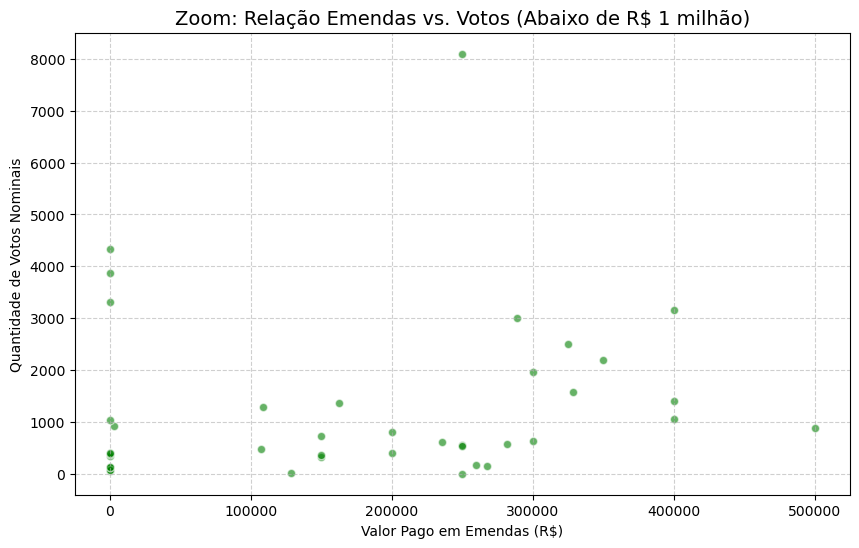

In [12]:
# 1. Criar uma nova tabela filtrando apenas valores menores que 1 milhão
dados_zoom = dados_finais[dados_finais['Valor pago'] < 1000000].copy()

# 2. Configurar o tamanho do gráfico
plt.figure(figsize=(10, 6))

# 3. Criar o gráfico de dispersão com os novos dados
plt.scatter(dados_zoom['Valor pago'], dados_zoom['QT_VOTOS_NOMINAIS'], 
            alpha=0.6, c='green', edgecolors='white') # Troquei a cor para verde pra diferenciar

# 4. Títulos e rótulos
plt.title('Zoom: Relação Emendas vs. Votos (Abaixo de R$ 1 milhão)', fontsize=14)
plt.xlabel('Valor Pago em Emendas (R$)')
plt.ylabel('Quantidade de Votos Nominais')
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Exibir
plt.show()

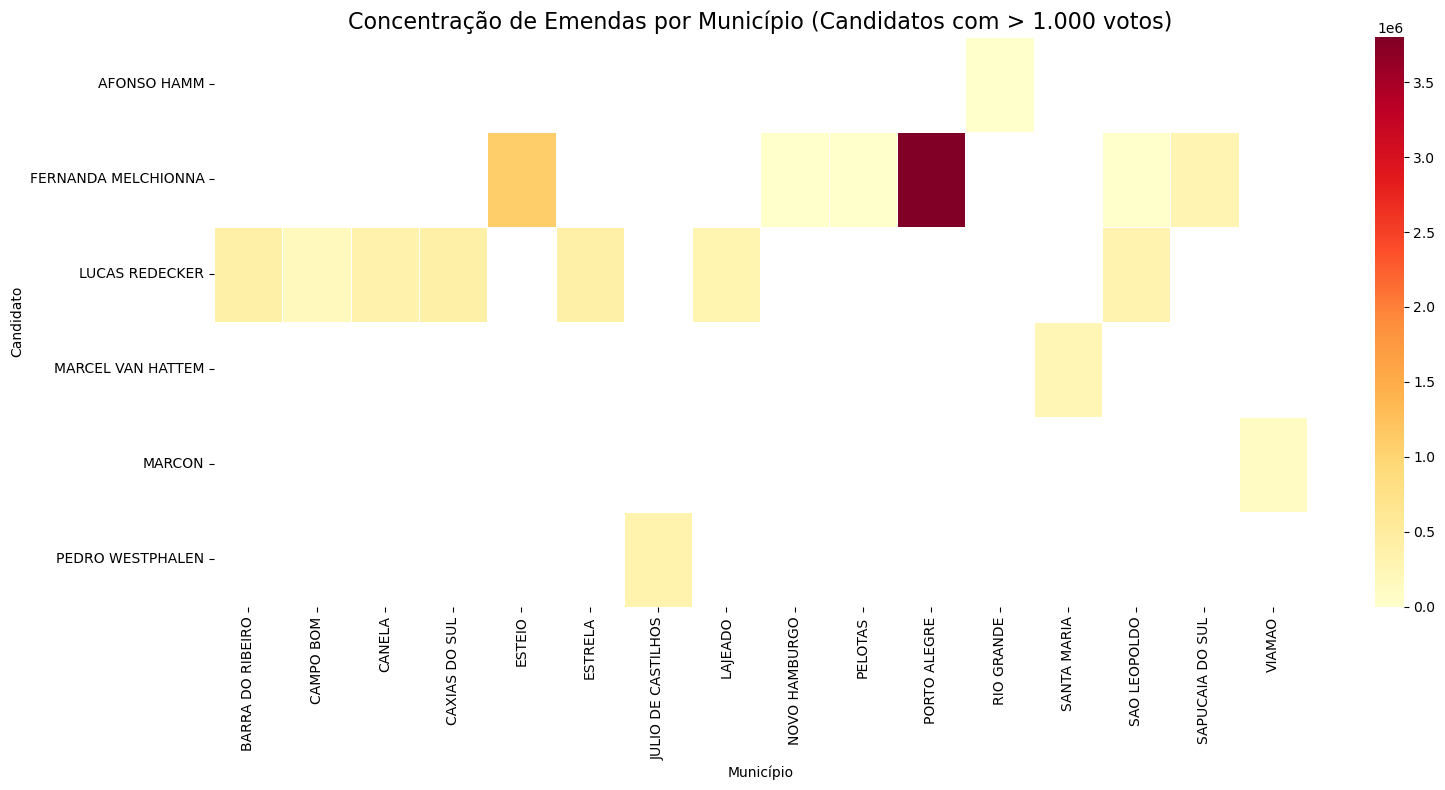

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aplicar o filtro de relevância (mínimo de 1.000 votos por candidato/município)
df_final_filtrado = dados_finais[dados_finais['QT_VOTOS_NOMINAIS'] >= 1000].copy()

# 2. Criar a matriz para o mapa (Pivot Table)
matriz_final = df_final_filtrado.pivot_table(index='CANDIDATO', columns='MUNICIPIO', values='Valor pago')

# 3. Desenhar o Mapa de Calor Final
plt.figure(figsize=(16, 8)) # Aumentamos um pouco o tamanho da tela para comportar mais cidades
sns.heatmap(matriz_final, cmap='YlOrRd', annot=False, linewidths=.5)

plt.title('Concentração de Emendas por Município (Candidatos com > 1.000 votos)', fontsize=16)
plt.xlabel('Município')
plt.ylabel('Candidato')
plt.tight_layout() # Garante que nada fique cortado
plt.show()

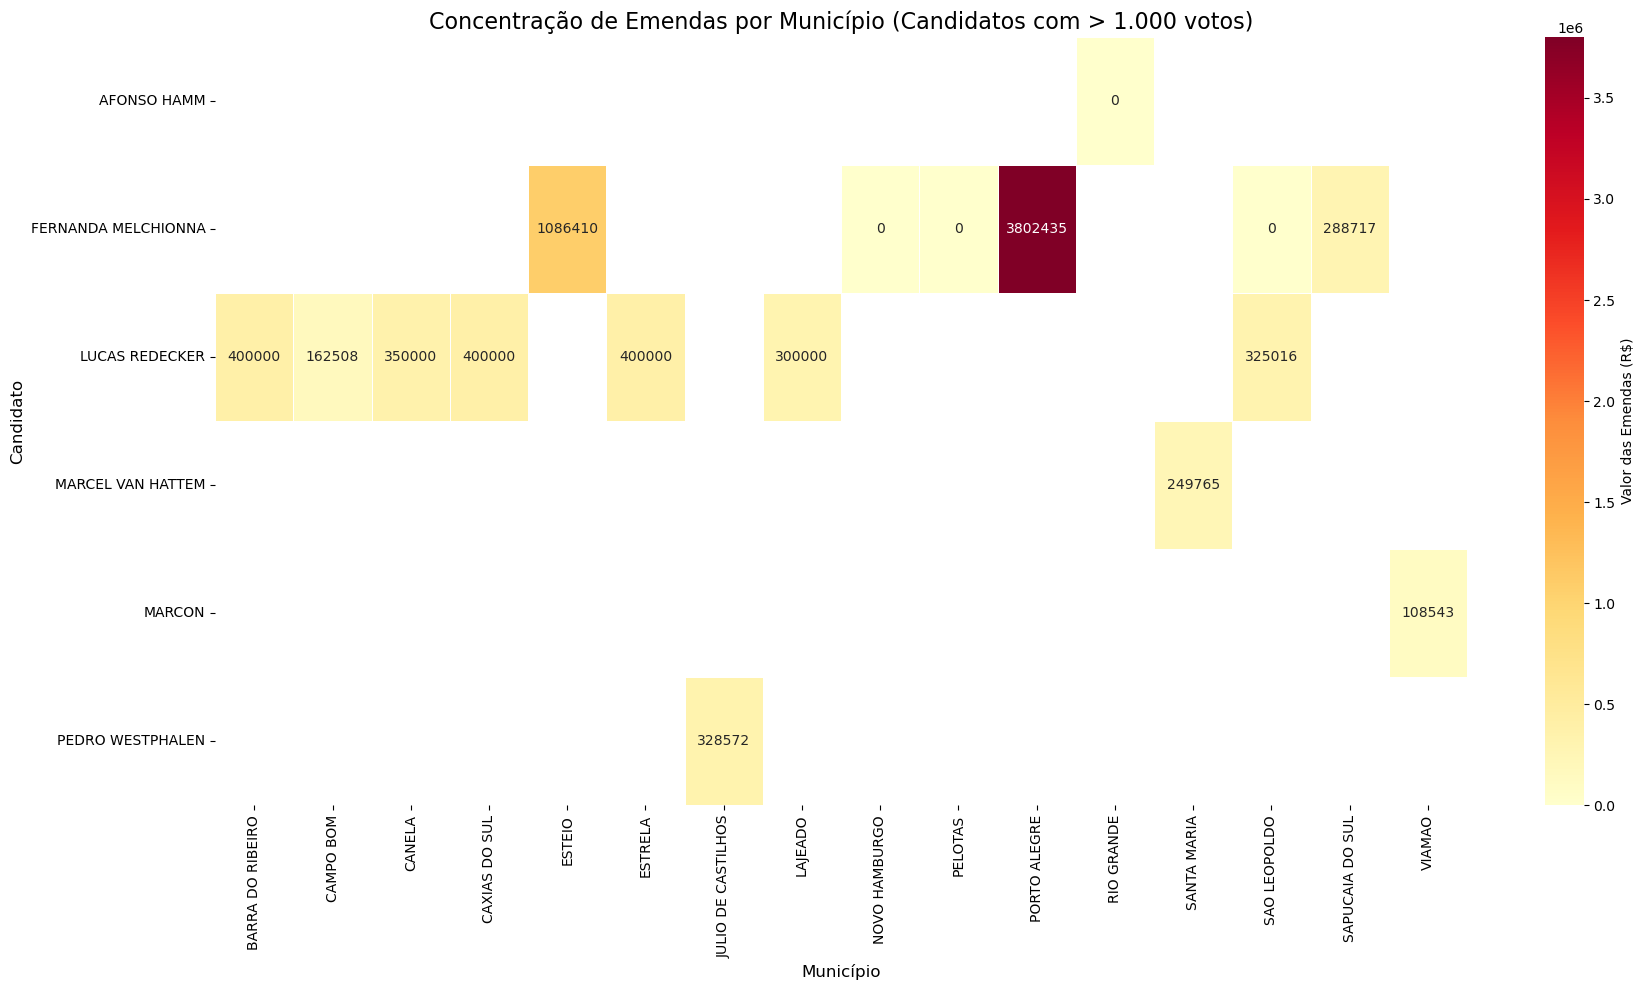

In [14]:
# 1. Configurar o tamanho da figura (um pouco maior para caber as anotações)
plt.figure(figsize=(18, 10)) 

# 2. Gerar o mapa com as anotações ligadas
# annot=True: exibe os valores
# fmt='.0f': remove casas decimais desnecessárias
# cbar_kws: adiciona um rótulo na barra lateral de cores
sns.heatmap(matriz_final, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=.5, 
            cbar_kws={'label': 'Valor das Emendas (R$)'})

# 3. Ajustes finais de legenda
plt.title('Concentração de Emendas por Município (Candidatos com > 1.000 votos)', fontsize=16)
plt.xlabel('Município', fontsize=12)
plt.ylabel('Candidato', fontsize=12)
plt.tight_layout()

# 4. Exibir
plt.show()

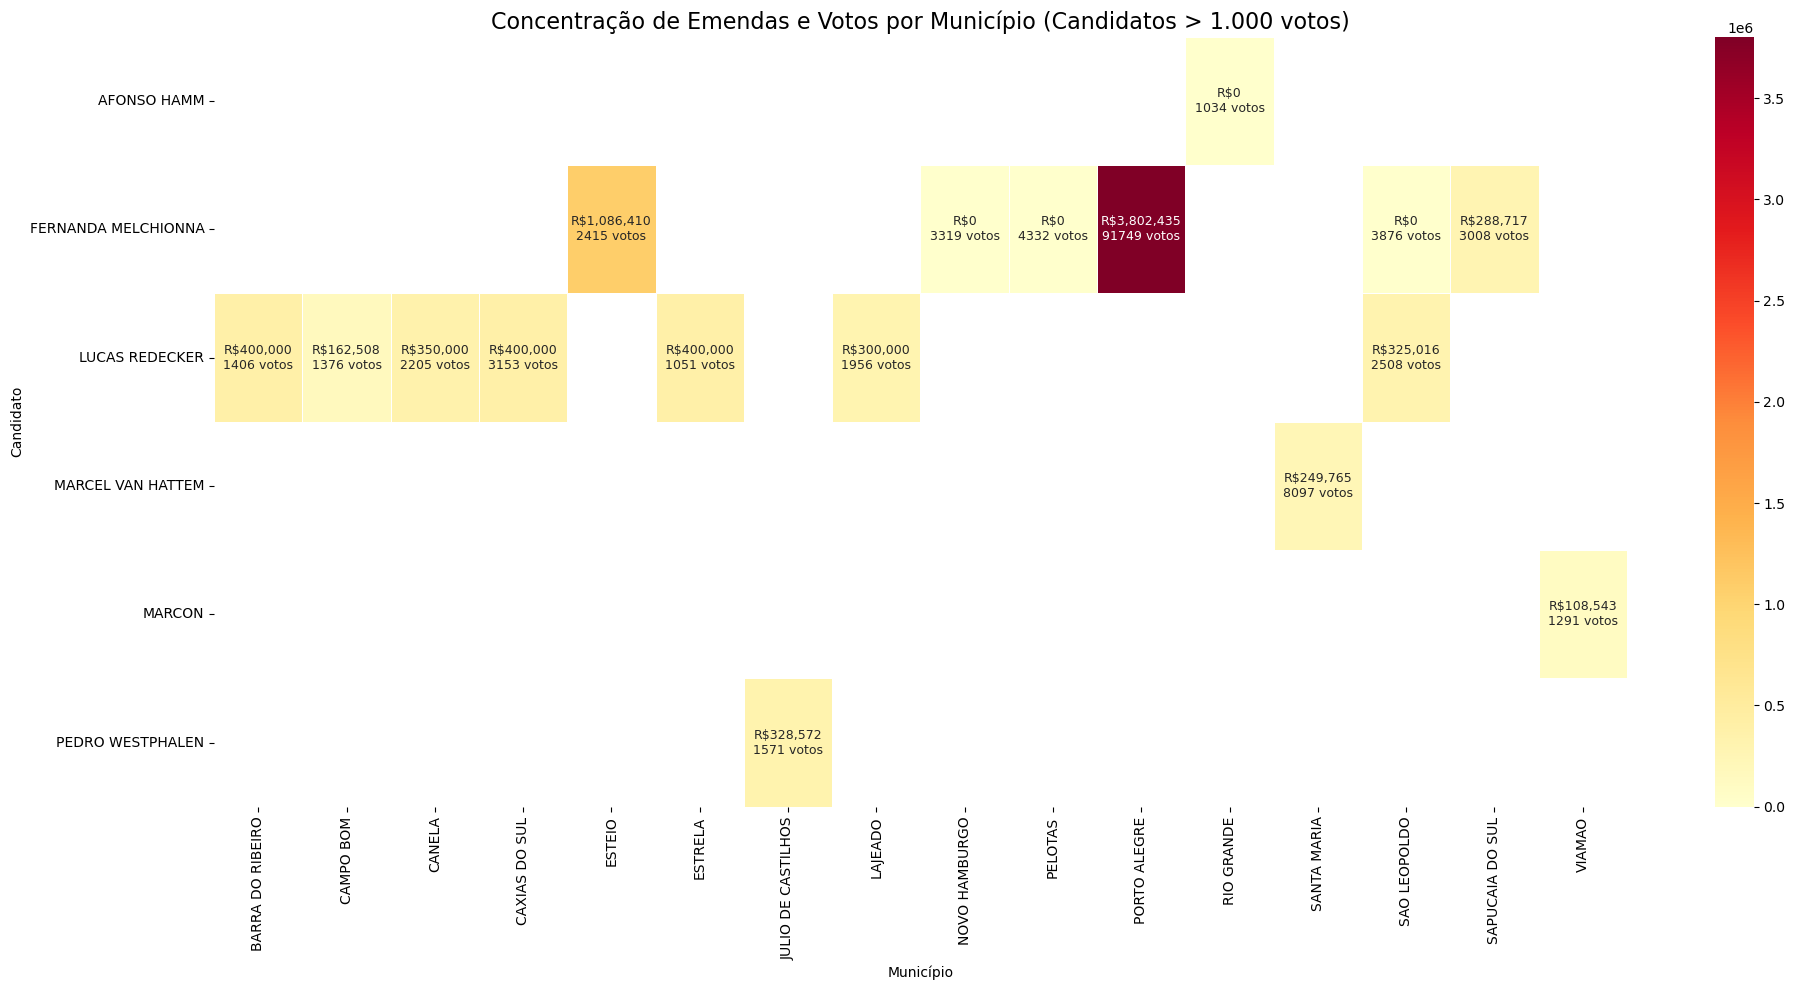

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Criar a matriz numérica para as CORES (o que gera o calor)
matriz_valores = df_final_filtrado.pivot_table(index='CANDIDATO', columns='MUNICIPIO', values='Valor pago')

# 2. Criar a matriz de TEXTO para as ANOTAÇÕES
def criar_label(row):
    # Formata o valor como moeda (sem casas decimais para não poluir) e votos como inteiro
    texto = f"R${row['Valor pago']:,.0f}\n{int(row['QT_VOTOS_NOMINAIS'])} votos"
    return texto

# Criamos uma tabela temporária com os textos formatados
df_labels = df_final_filtrado.copy()
df_labels['label'] = df_labels.apply(criar_label, axis=1)
matriz_labels = df_labels.pivot(index='CANDIDATO', columns='MUNICIPIO', values='label')
# Preenchemos os vazios (onde não há emenda) com vazio ""
matriz_labels = matriz_labels.fillna('')

# 3. Desenhar o Mapa
plt.figure(figsize=(20, 10))
# annot=matriz_labels: passamos nossa tabela de textos personalizada
# fmt='': dizemos ao Seaborn que não precisa formatar nada, pois já está no formato de texto
sns.heatmap(matriz_valores, annot=matriz_labels, fmt='', cmap='YlOrRd', linewidths=.5, annot_kws={"size": 9})

plt.title('Concentração de Emendas e Votos por Município (Candidatos > 1.000 votos)', fontsize=16)
plt.xlabel('Município')
plt.ylabel('Candidato')
plt.tight_layout()
plt.show()

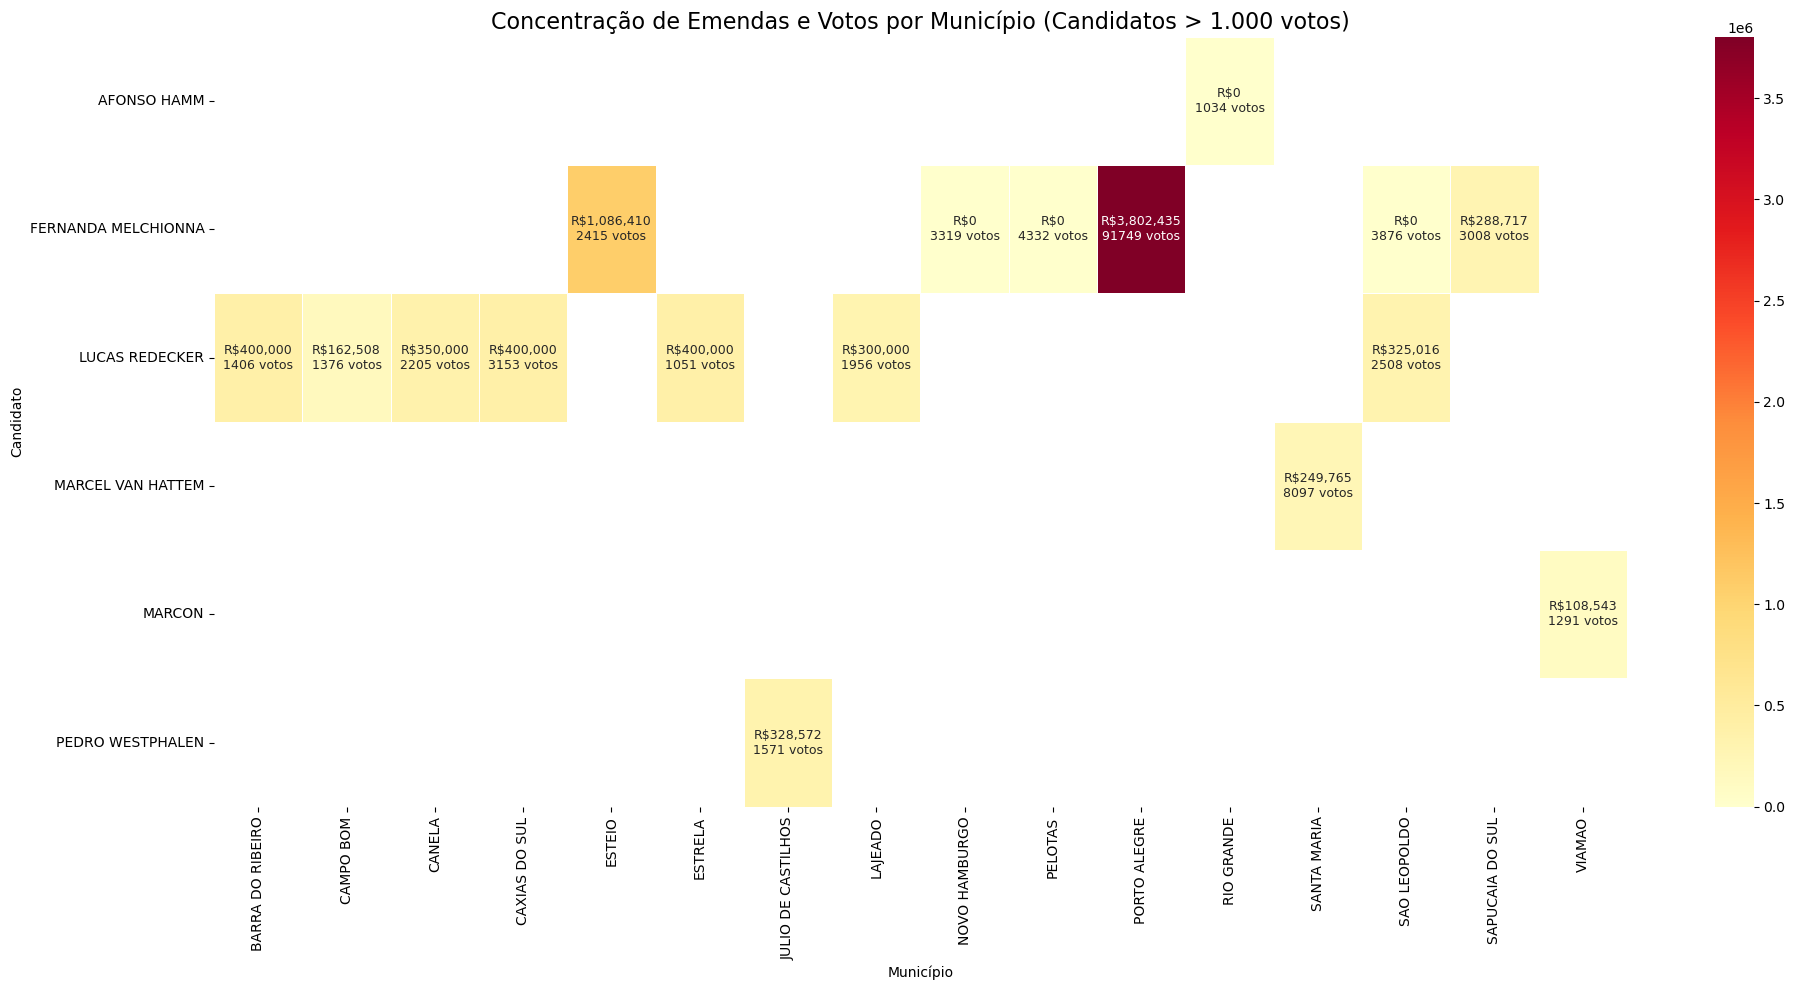

In [17]:
# 1. Desenhar o mapa (tudo igual ao que fizemos antes)
plt.figure(figsize=(20, 10))
sns.heatmap(matriz_valores, annot=matriz_labels, fmt='', cmap='YlOrRd', linewidths=.5, annot_kws={"size": 9})
plt.title('Concentração de Emendas e Votos por Município (Candidatos > 1.000 votos)', fontsize=16)
plt.xlabel('Município')
plt.ylabel('Candidato')
plt.tight_layout()

# 2. SALVAR ANTES DE MOSTRAR
plt.savefig('mapa_emendas_votos.pdf', dpi=300, bbox_inches='tight')

# 3. Mostrar depois
plt.show()

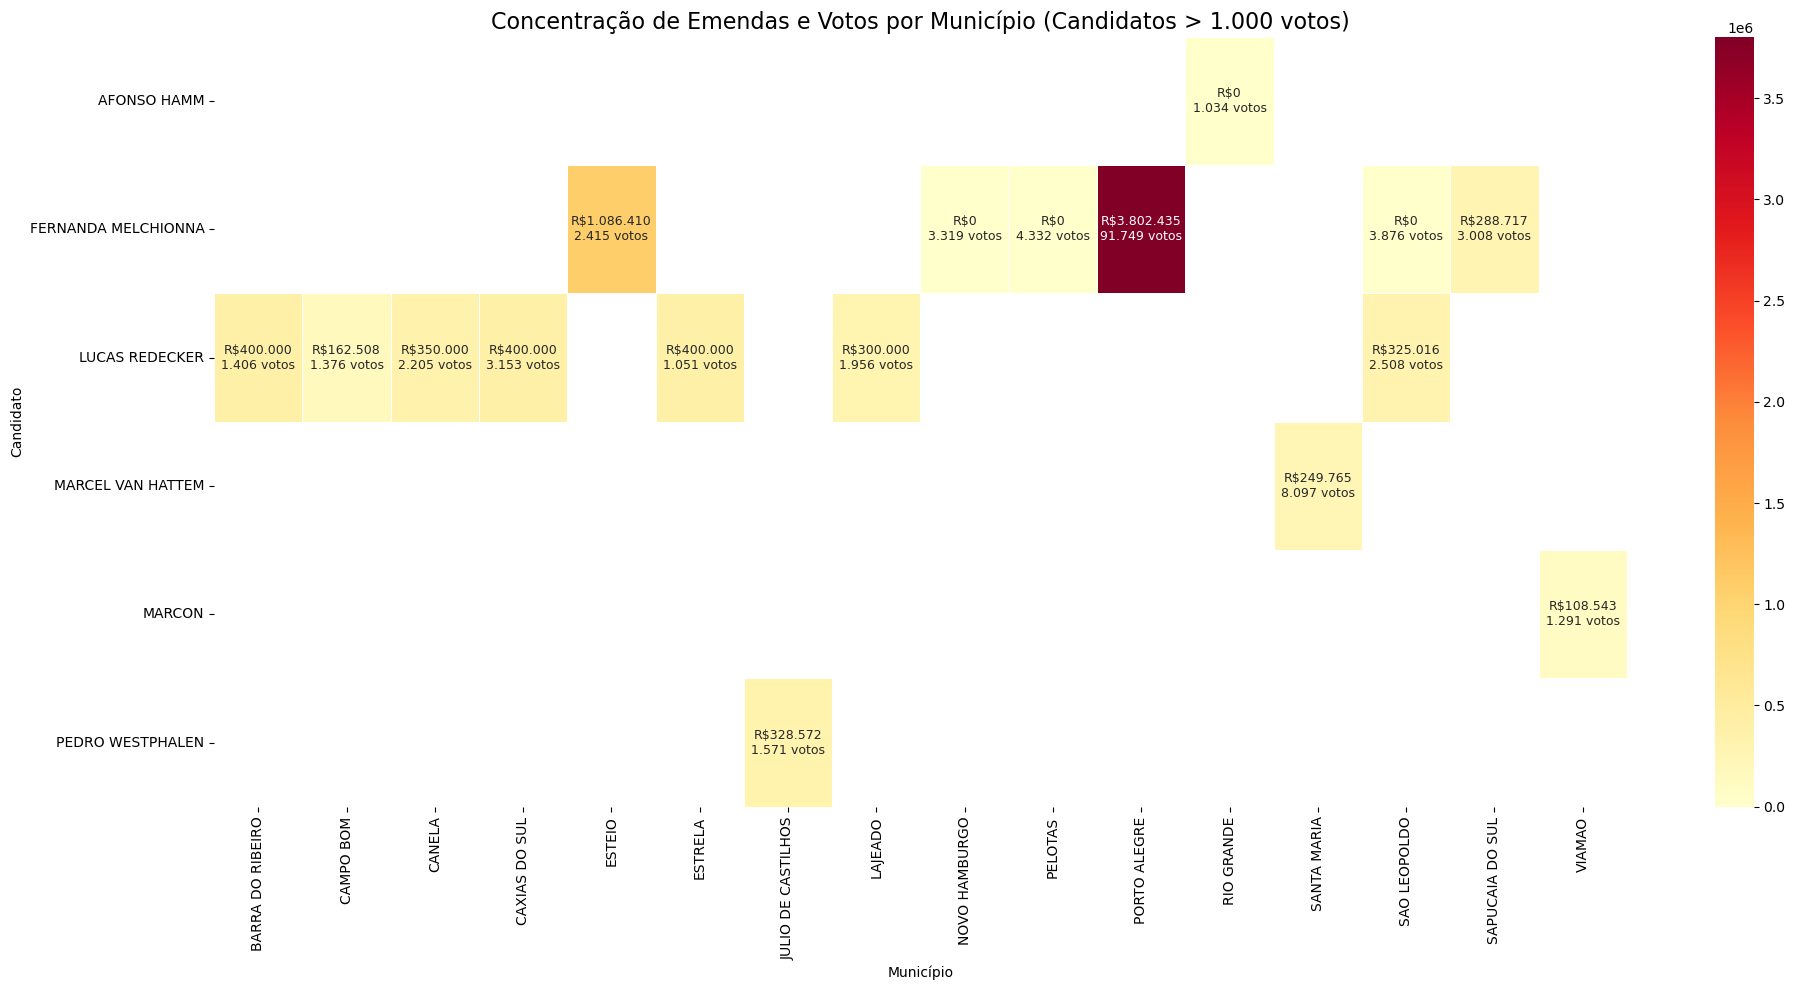

In [18]:
# 1. Ajuste na função para incluir separador de milhar (ponto)
def criar_label(row):
    # Formata valor pago: coloca vírgula, depois substitui por ponto para o padrão BR
    valor_fmt = f"{row['Valor pago']:,.0f}".replace(',', '.')
    
    # Formata votos: converte para inteiro, coloca vírgula, depois substitui por ponto
    votos_fmt = f"{int(row['QT_VOTOS_NOMINAIS']):,}".replace(',', '.')
    
    # Monta o texto
    texto = f"R${valor_fmt}\n{votos_fmt} votos"
    return texto

# 2. Criar a matriz de texto com a função atualizada
df_labels = df_final_filtrado.copy()
df_labels['label'] = df_labels.apply(criar_label, axis=1)
matriz_labels = df_labels.pivot(index='CANDIDATO', columns='MUNICIPIO', values='label')
matriz_labels = matriz_labels.fillna('')

# 3. Desenhar o Mapa (O resto permanece igual)
plt.figure(figsize=(20, 10))
sns.heatmap(matriz_valores, annot=matriz_labels, fmt='', cmap='YlOrRd', linewidths=.5, annot_kws={"size": 9})

plt.title('Concentração de Emendas e Votos por Município (Candidatos > 1.000 votos)', fontsize=16)
plt.xlabel('Município')
plt.ylabel('Candidato')
plt.tight_layout()

# 4. Salvar (Lembre-se: salvar ANTES do show!)
plt.savefig('mapa_emendas_votos_final.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [19]:
!pip install geopandas plotly dash

   ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
   ---------------------------- ----------- 5.2/7.3 MB 24.1 MB/s eta 0:00:01
   ---------------------------------------- 7.3/7.3 MB 23.5 MB/s  0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   --------- ------------------------------ 5.2/22.9 MB 25.4 MB/s eta 0:00:01
   ------------------ --------------------- 10.5/22.9 MB 25.3 MB/s eta 0:00:01
   -------------------------- ------------- 15.5/22.9 MB 25.2 MB/s eta 0:00:01
   ------------------------------------ --- 20.7/22.9 MB 25.2 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 24.1 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------- ----- 5.5/6.3 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 23.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------

In [20]:
import geopandas as gpd

# Carregar o arquivo
gdf = gpd.read_file('municipios_rs.geojson')

# Exibir as informações para identificarmos a coluna de nomes
print("--- COLUNAS DISPONÍVEIS NO ARQUIVO ---")
print(gdf.columns.tolist())

print("\n--- AMOSTRA DOS DADOS (Primeiras 5 linhas) ---")
print(gdf.head())

--- COLUNAS DISPONÍVEIS NO ARQUIVO ---
['id', 'name', 'description', 'geometry']

--- AMOSTRA DOS DADOS (Primeiras 5 linhas) ---
        id        name description  \
0  4300034      Aceguá      Aceguá   
1  4300059  Água Santa  Água Santa   
2  4300109       Agudo       Agudo   
3  4300208   Ajuricaba   Ajuricaba   
4  4300307     Alecrim     Alecrim   

                                            geometry  
0  POLYGON ((-54.11276 -31.42931, -54.09821 -31.4...  
1  POLYGON ((-52.04263 -28.11703, -52.03489 -28.1...  
2  POLYGON ((-53.2556 -29.44736, -53.23478 -29.46...  
3  POLYGON ((-53.78588 -28.1127, -53.78654 -28.12...  
4  POLYGON ((-54.78557 -27.57626, -54.77463 -27.5...  


In [21]:
# 1. Garantir que ambos os nomes estejam em maiúsculas para o cruzamento
gdf['name_upper'] = gdf['name'].str.upper()
df_final_filtrado['MUNICIPIO_UPPER'] = df_final_filtrado['MUNICIPIO'].str.upper()

# 2. Fazer o cruzamento (merge)
# Queremos manter as geometrias do mapa e adicionar os dados políticos nelas
gdf_merged = gdf.merge(df_final_filtrado, left_on='name_upper', right_on='MUNICIPIO_UPPER', how='left')

# 3. Verificar o resultado
# Contar quantos municípios receberam dados (tiveram match)
municipios_com_dados = gdf_merged['QT_VOTOS_NOMINAIS'].notna().sum()
print(f"Total de municípios no mapa: {len(gdf)}")
print(f"Municípios com dados políticos cruzados: {municipios_com_dados}")

if municipios_com_dados == 0:
    print("Atenção: Nenhum município cruzou! Verifique se os nomes batem.")
else:
    print("Sucesso! Os dados foram vinculados ao mapa.")

Total de municípios no mapa: 496
Municípios com dados políticos cruzados: 13
Sucesso! Os dados foram vinculados ao mapa.


In [47]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd
import geopandas as gpd

# --- Inicialização ---
app = Dash(__name__)

# --- Layout ---
app.layout = html.Div([
    html.H1("Painel de Controle: Emendas e Votação por Município"),
    html.Label("Selecione o Candidato:"),
    dcc.Dropdown(
        id='dropdown-candidato',
        options=[{'label': i, 'value': i} for i in df_final_filtrado['CANDIDATO'].unique()],
        value=df_final_filtrado['CANDIDATO'].unique()[0]
    ),
    dcc.Graph(id='mapa-interativo', style={'height': '80vh'})
])

# --- Lógica do Mapa ---
@app.callback(
    Output('mapa-interativo', 'figure'),
    Input('dropdown-candidato', 'value')
)
def update_map(selected_candidato):
    # 1. Filtra dados do candidato
    df_candidato = df_final_filtrado[df_final_filtrado['CANDIDATO'] == selected_candidato].copy()
    
    # 2. Merge com o mapa base
    gdf_plot = gdf.merge(df_candidato, left_on='name_upper', right_on='MUNICIPIO_UPPER', how='left')
    
    # 3. Trata os nulos
    gdf_plot['Valor pago'] = gdf_plot['Valor pago'].fillna(0)
    
    # 4. Cria o mapa
    fig = px.choropleth(
        gdf_plot,
        geojson=gdf_plot.geometry, 
        locations=gdf_plot.index,
        color='Valor pago',
        hover_name='name',
        # ADICIONAMOS AQUI: As colunas que queremos mostrar no mouse
        custom_data=['Valor pago', 'QT_VOTOS_NOMINAIS'], 
        color_continuous_scale="YlOrRd", 
        title=f"Distribuição de Emendas: {selected_candidato}"
    )
    
    # 5. AJUSTE DO HOVER: Formatamos como o texto aparece
    # %{customdata[0]} refere-se ao primeiro item do custom_data (Valor pago)
    # %{customdata[1]} refere-se ao segundo item (QT_VOTOS_NOMINAIS)
    fig.update_traces(
        hovertemplate="<b>%{hovertext}</b><br>Valor Total: R$ %{customdata[0]:,.2f}<br>Votos: %{customdata[1]:,.0f}<extra></extra>",
        marker_line_width=0.5,
        marker_line_color='white'
    )
    
    # 6. Ajuste fino do layout (Mantendo o seu fitbounds que já está ok)
    fig.update_geos(
        fitbounds="locations", 
        visible=False
    )
    
    fig.update_layout(
        margin={"r":0,"t":50,"l":0,"b":0},
        geo=dict(bgcolor='white', showland=True, landcolor='#f0f0f0', showframe=False)
    )
    
    return fig

# --- Execução ---
if __name__ == '__main__':
    app.run(debug=True)